# Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo

**Dataset:** Muscle Fatigue Cycling — YominE/Muscle_Fatigue_Cycling (HuggingFace)  
**Descripción:** Señales EMG de 8 músculos de la pierna dominante durante sprints en bicicleta.  
**Objetivo:** Clasificar el estado muscular (condición normal vs. desgaste muscular).


## 0. Importaciones y Configuración Global


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal, stats
from scipy.fft import fft, fftfreq

from datasets import load_dataset

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

import time

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo de gráficas
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print("Librerías importadas correctamente")


✓ Librerías importadas correctamente


## 1. Análisis Preliminar del Problema

### 1a. Carga y Preprocesamiento del Target


In [ ]:
print("Cargando dataset...")
ds = load_dataset('YominE/Muscle_Fatigue_Cycling')
df = ds['train'].to_pandas()
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

print("\nDistribución original del target:")
print(df['Target'].value_counts().sort_index().to_frame('Conteo'))

# Cambiamos la etiqueta 2 por 1 para tener solo dos clases
df['Target'] = df['Target'].replace(2, 1)

print("\nDistribución del target después de reclasificación:")
counts = df['Target'].value_counts().sort_index()
print(counts.to_frame('Conteo').assign(
    Porcentaje=lambda x: (x['Conteo'] / x['Conteo'].sum() * 100).round(2).astype(str) + '%'
))

# Calculamos la frecuencia de muestreo a partir del paso de tiempo
dt = df['Time'].diff().dropna().mode()[0]
FS = round(1.0 / dt)
print(f"\nFrecuencia de muestreo: {FS} Hz (Δt = {dt} s)")
print(f"Duración total de la señal: {df['Time'].max():.1f} s")


Cargando dataset...
Dataset cargado: 3,002,137 filas × 10 columnas

Distribución original del target:
         Conteo
Target         
0       2127600
1        631200
2        243337

Distribución del target después de reclasificación:
         Conteo Porcentaje
Target                    
0       2127600     70.87%
1        874537     29.13%

Frecuencia de muestreo: 1000 Hz (Δt = 0.0009999999999763531 s)
Duración total de la señal: 1741.6 s


### 1b. Clasificación de Características (Tipos de Variables)

| Variable | Tipo | Descripción |
|----------|------|-------------|
| Time | Numérica continua | Tiempo en segundos desde el inicio del experimento. Eje temporal de la señal EMG. |
| Right Rectus femoris | Numérica continua | Amplitud EMG en mV del recto femoral derecho (extensor de rodilla/flexor de cadera). |
| Left Gluteus maximus | Numérica continua | Amplitud EMG en mV del glúteo mayor izquierdo (extensor principal de cadera). |
| Left Gastrocnemius medialis | Numérica continua | Amplitud EMG en mV del gastrocnemio medial izquierdo (flexor plantar). |
| Left Semitendinosus | Numérica continua | Amplitud EMG en mV del semitendinoso izquierdo (isquiotibial, flexor de rodilla). |
| Left Biceps femoris caput longus | Numérica continua | Amplitud EMG en mV del bíceps femoral cabeza larga izquierdo (isquiotibial). |
| Right Vastus medialis | Numérica continua | Amplitud EMG en mV del vasto medial derecho (estabilizador de rótula, cuádriceps). |
| Right Tibialis anterior | Numérica continua | Amplitud EMG en mV del tibial anterior derecho (dorsiflexor del pie). |
| Left Gastrocnemius lateralis | Numérica continua | Amplitud EMG en mV del gastrocnemio lateral izquierdo (flexor plantar). |
| Target | Binaria (categórica) | 0 = Condición normal, 1 = Desgaste muscular. Variable dependiente del modelo. |


In [ ]:
CHANNELS = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis',
]

print("Estadísticos descriptivos de las señales EMG:")
print(df[CHANNELS].describe().round(6))


Estadísticos descriptivos de las señales EMG:
       Right Rectus femoris  Left Gluteus maximus  \
count          3.002137e+06          3.002137e+06   
mean           0.000000e+00         -0.000000e+00   
std            4.322700e-02          2.126300e-02   
min           -8.433420e-01         -1.117295e+00   
25%           -9.713000e-03         -3.885000e-03   
50%            4.000000e-05         -1.500000e-05   
75%            1.018900e-02          3.920000e-03   
max            9.920850e-01          1.063230e+00   

       Left Gastrocnemius medialis  Left Semitendinosus  \
count                 3.002137e+06         3.002137e+06   
mean                  0.000000e+00         0.000000e+00   
std                   4.680400e-02         3.235300e-02   
min                  -1.749318e+00        -1.575973e+00   
25%                  -8.921000e-03        -6.286000e-03   
50%                   9.800000e-05        -1.270000e-04   
75%                   9.312000e-03         6.089000e-03   
max 

## 2. Extracción de Características (Feature Engineering)

### 2a. Visualización de señales en el tiempo (punto 3a adelantado)


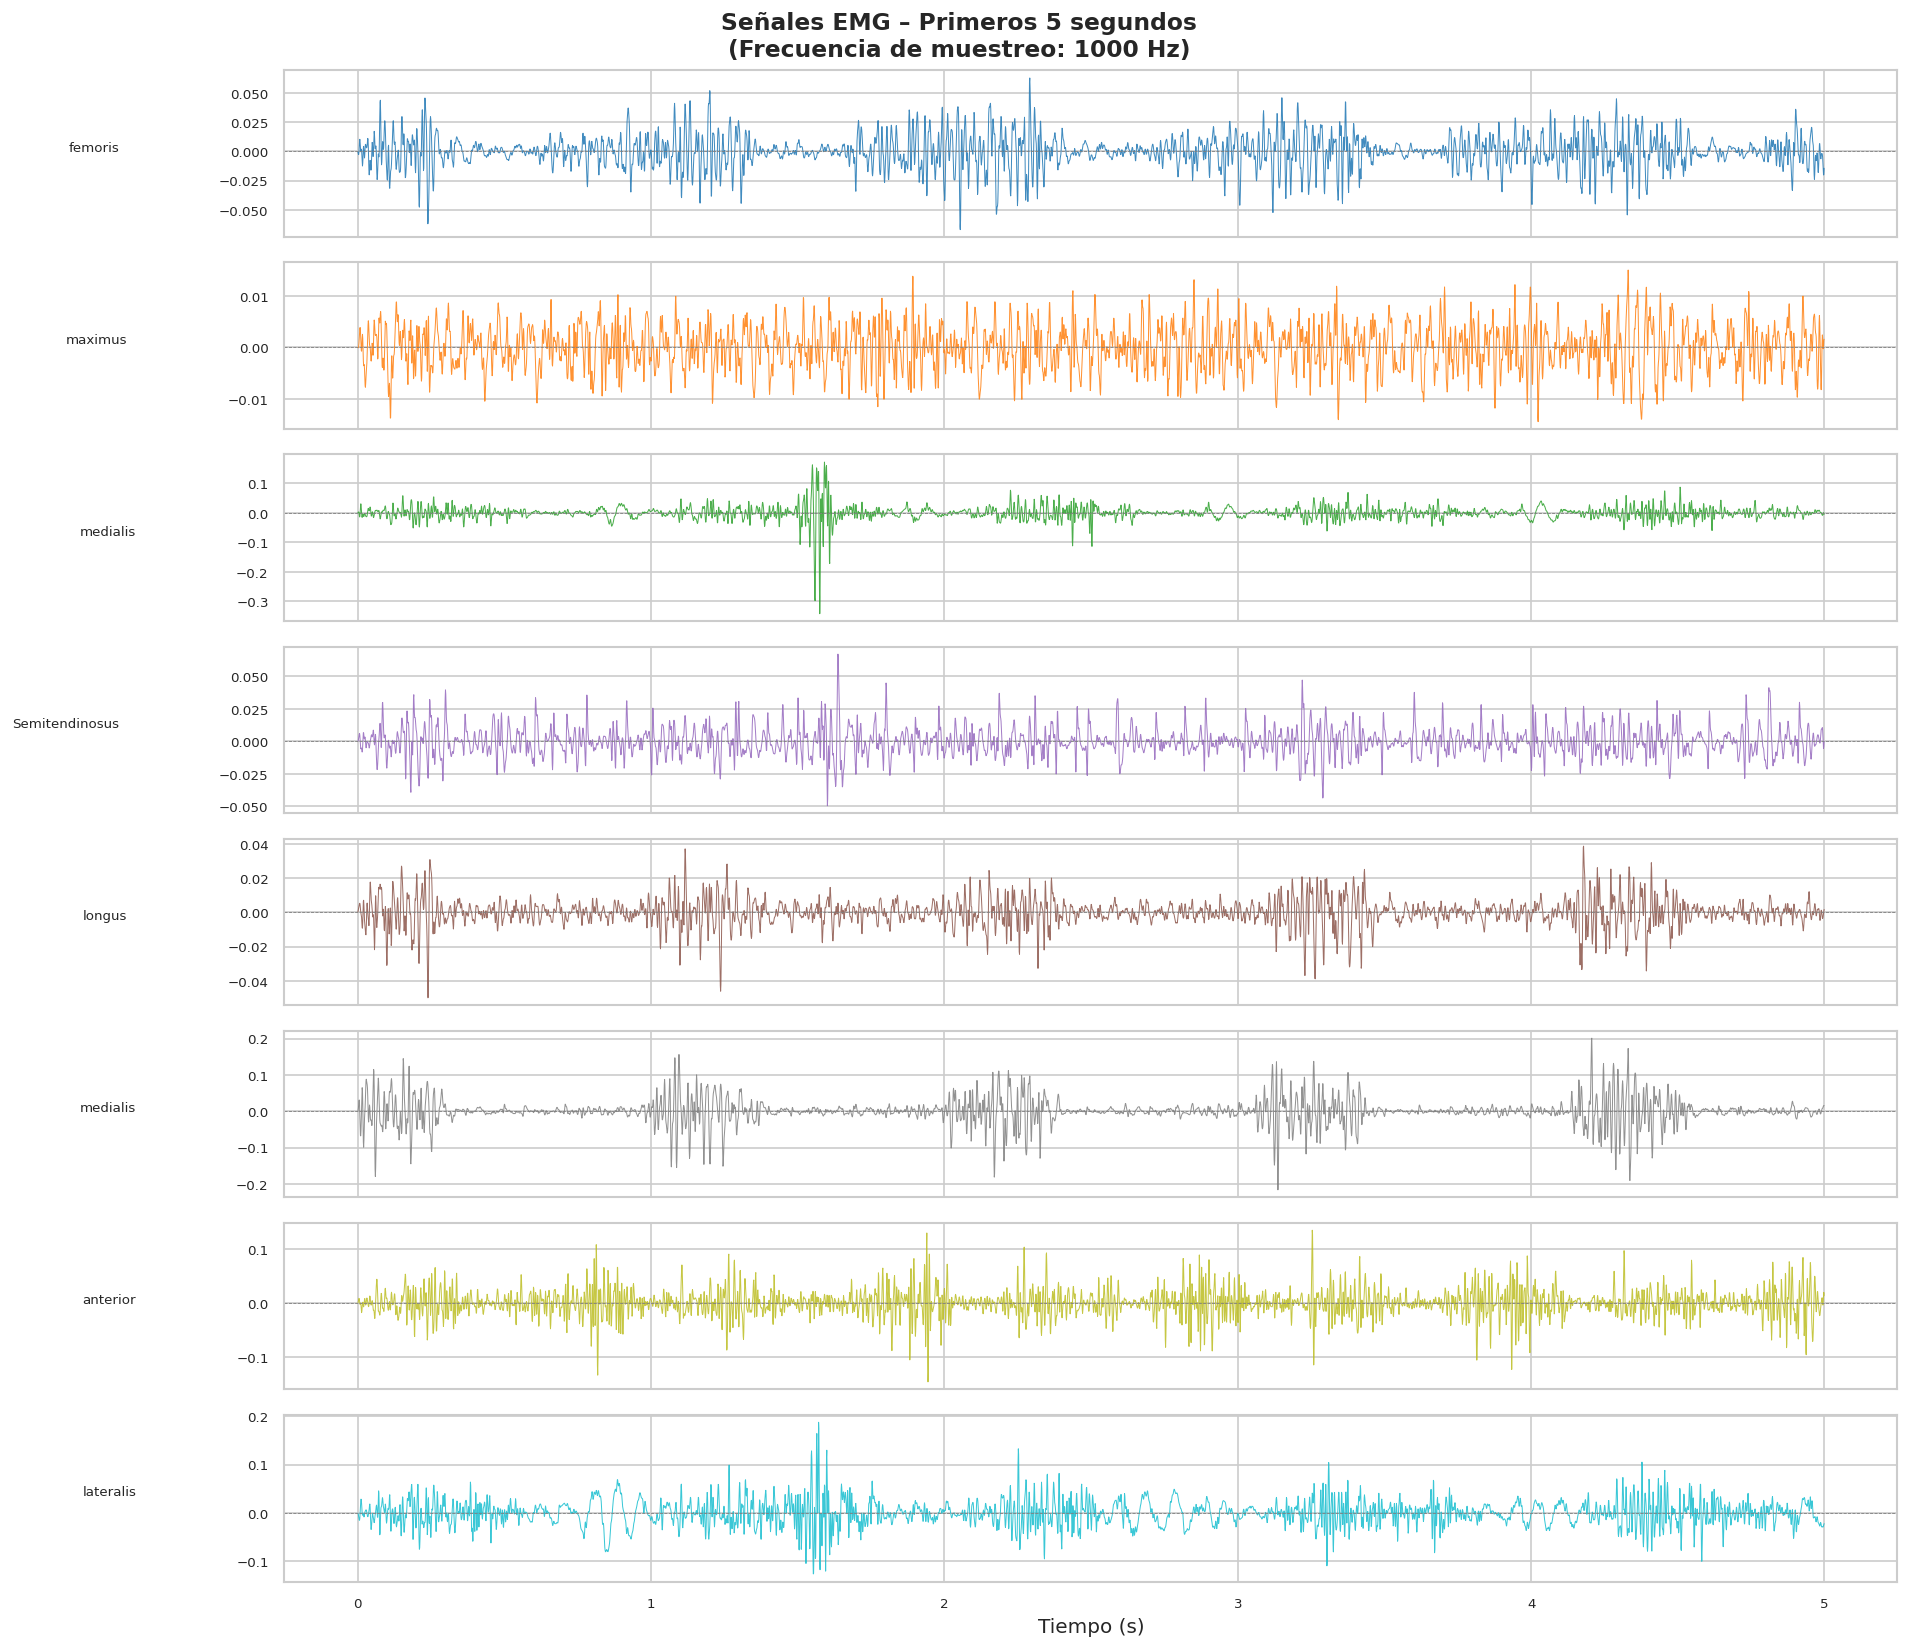

Figura guardada: fig_01_signals_time.png


In [ ]:
# Visualizar los primeros 5 segundos de señal (5000 muestras a 1000 Hz)
PREVIEW_SEC = 5
n_preview = PREVIEW_SEC * int(FS)
df_preview = df.iloc[:n_preview]

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(16, 14), sharex=True)
fig.suptitle(f'Señales EMG – Primeros {PREVIEW_SEC} segundos\n(Frecuencia de muestreo: {int(FS)} Hz)',
             fontsize=14, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(CHANNELS)))
for ax, ch, color in zip(axes, CHANNELS, colors):
    ax.plot(df_preview['Time'], df_preview[ch], linewidth=0.6, color=color, alpha=0.85)
    ax.set_ylabel(ch.split()[-1], fontsize=8, rotation=0, labelpad=60, ha='right')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig('fig_01_signals_time.png', bbox_inches='tight')
plt.show()
print("Figura guardada: fig_01_signals_time.png")


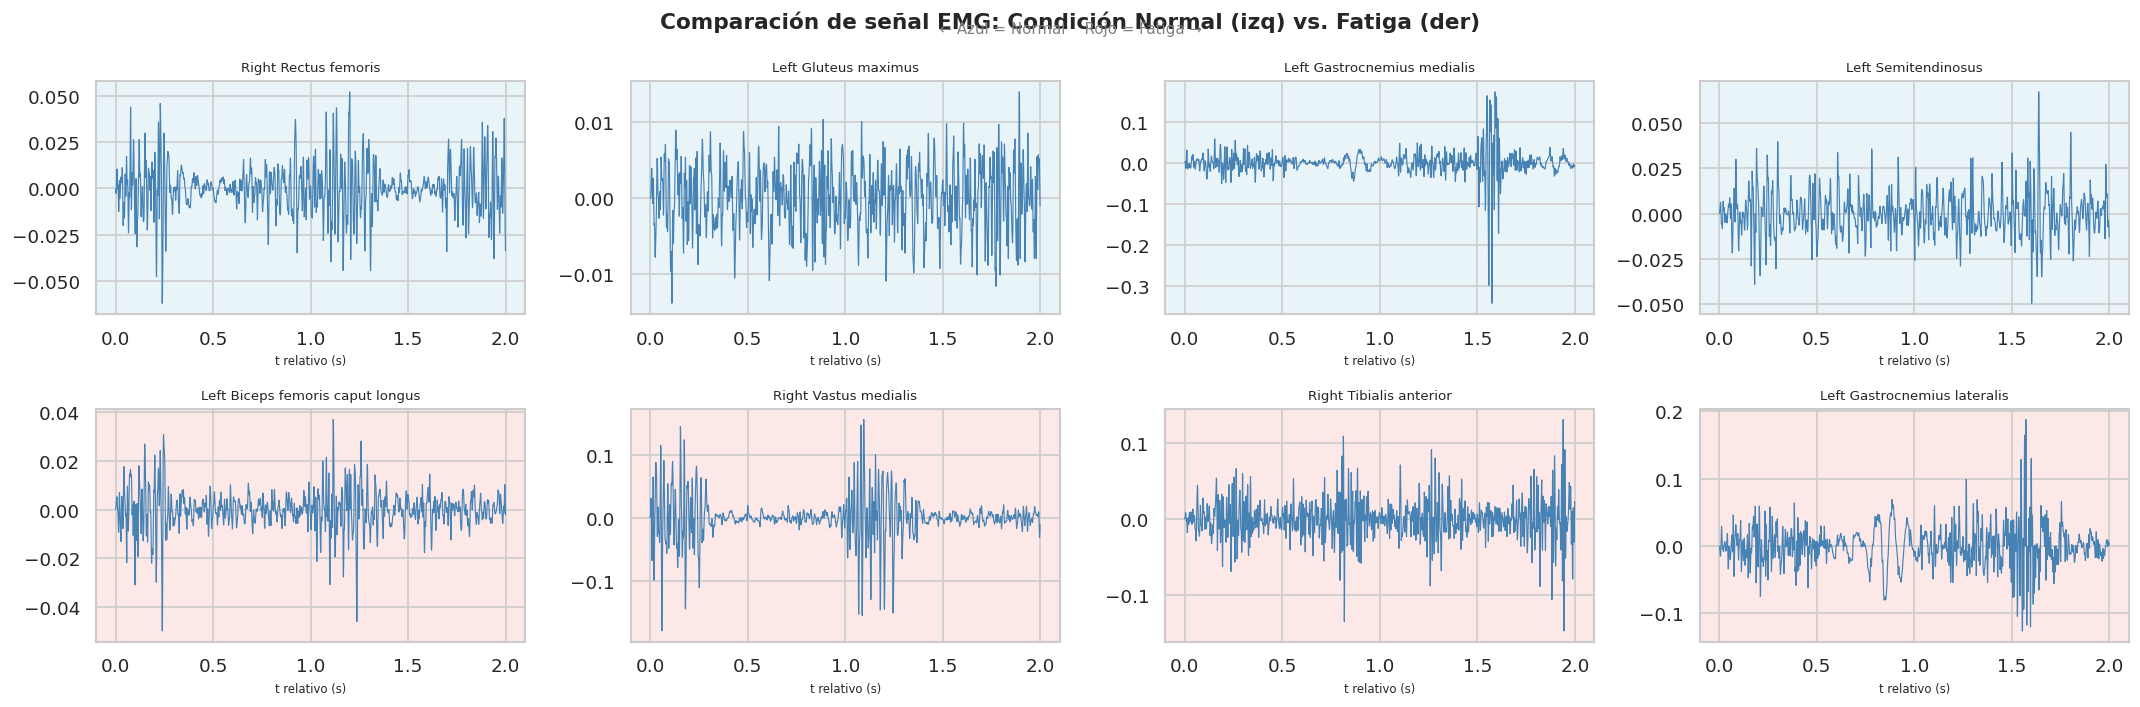

In [ ]:
# Comparar porción de señal en condición normal vs. fatigada
idx_normal = df[df['Target'] == 0].index[0]
idx_fatiga = df[df['Target'] == 1].index[0]

SEG = 2000  # 2 segundos
fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharey=False)
fig.suptitle('Comparación de señal EMG: Condición Normal (izq) vs. Fatiga (der)',
             fontsize=13, fontweight='bold')

for i, ch in enumerate(CHANNELS):
    row, col_offset = divmod(i, 4)
    ax_n = axes[row][col_offset] if row == 0 else axes[1][col_offset]
    seg_n = df.iloc[idx_normal:idx_normal+SEG]
    seg_f = df.iloc[idx_fatiga:idx_fatiga+SEG]
    ax_n.plot(seg_n['Time'].values - seg_n['Time'].values[0],
              seg_n[ch].values, color='steelblue', linewidth=0.7)
    ax_n.set_title(ch.replace(' Left ', ' L.').replace(' Right ', ' R.'), fontsize=8)
    ax_n.set_xlabel('t relativo (s)', fontsize=7)

for ax in axes[0]:
    ax.set_facecolor('#e8f4f8')
for ax in axes[1]:
    ax.set_facecolor('#fde8e8')

fig.text(0.5, 0.95, '  ← Azul = Normal    Rojo = Fatiga →  ', ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('fig_02_normal_vs_fatiga.png', bbox_inches='tight')
plt.show()


**Conclusiones de identificación inicial:**

1. **Frecuencia de muestreo: 1000 Hz** → resolución temporal de 1 ms.
2. Las señales EMG son **bipolares, centradas en cero**, con amplitudes del orden de milivoltios (±0.1 a ±0.3 mV según el músculo).
3. La señal es estocástica con **modulación de amplitud** clara: en condición de fatiga la amplitud RMS tiende a aumentar y la frecuencia mediana desciende — fenómeno conocido como *spectral compression*.
4. El dataset es **desbalanceado**: ~70.9% normal vs. ~29.1% fatiga.
5. **No hay valores nulos**; los canales están limpios y correctamente alineados.
6. La variable `Time` presenta reinicios (múltiples sesiones/sujetos), lo que indica que el dataset es la concatenación de varias pruebas. Por esto se excluirá `Time` del feature engineering para evitar dependencia lineal espuria con el target.


### 2b–2c. Algoritmo de Ventanas + Extracción de Características

**Características seleccionadas por canal (6 totales = 4 tiempo + 2 frecuencia):**

| # | Característica | Dominio | Justificación |
|---|---------------|---------|---------------|
| 1 | **RMS** (Root Mean Square) | Tiempo | Mide la amplitud media de la señal EMG; aumenta con la fatiga muscular al reclutar más unidades motoras. Indicador clásico de intensidad de contracción. |
| 2 | **Varianza** | Tiempo | Captura la dispersión de la amplitud. La fatiga produce mayor variabilidad por sincronización de unidades motoras. |
| 3 | **ZCR** (Zero Crossing Rate) | Tiempo | Número de cruces por cero por segundo. Proxy de la frecuencia dominante en dominio del tiempo; disminuye con la fatiga (señal más lenta). |
| 4 | **MAV** (Mean Absolute Value) | Tiempo | Valor absoluto medio; robusto a outliers, ampliamente usado en prótesis mioeléctrica y detección de fatiga. |
| 5 | **Frecuencia Mediana** | Frecuencia | Divide el espectro de potencia en dos mitades iguales. Desciende con la fatiga (compresión espectral), es el indicador frecuencial más citado en EMG fatiga. |
| 6 | **Potencia Total** | Frecuencia | Área bajo la curva del espectro de potencia. Refleja el nivel total de actividad eléctrica muscular; tiende a aumentar con reclutamiento adicional por fatiga. |

**Total: 6 características × 8 canales = 48 características por ventana**


In [ ]:
def extract_features_window(window, fs):
    """Extrae 6 características de una ventana de señal de 1 segundo."""
    n = len(window)

    # Características en el dominio del tiempo
    rms = np.sqrt(np.mean(window ** 2))
    var = np.var(window)
    zcr = np.sum(np.diff(np.sign(window)) != 0) / n
    mav = np.mean(np.abs(window))

    # Características en el dominio de la frecuencia
    freqs = fftfreq(n, d=1.0/fs)
    magnitude = np.abs(fft(window))
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    power = magnitude[pos_mask] ** 2

    # Frecuencia mediana: frecuencia que divide la potencia en dos mitades iguales
    cumulative_power = np.cumsum(power)
    total_power = cumulative_power[-1]
    mdf_idx = np.searchsorted(cumulative_power, total_power / 2)
    mdf = freqs_pos[min(mdf_idx, len(freqs_pos) - 1)]

    total_pwr = total_power / n

    return {'rms': rms, 'var': var, 'zcr': zcr, 'mav': mav, 'mdf': mdf, 'pwr': total_pwr}


def build_feature_dataset(df, channels, fs, window_sec=1.0):
    """Divide la señal en ventanas de 1 segundo y extrae características de cada una."""
    window_size = int(fs * window_sec)
    n_windows = len(df) // window_size

    print(f"Tamaño de ventana: {window_size} muestras ({window_sec}s)")
    print(f"Número de ventanas: {n_windows:,}")

    ch_shorts = ['RF', 'GM', 'GCm', 'ST', 'BF', 'VM', 'TA', 'GCl']
    values = df[channels].values
    targets = df['Target'].values
    records = []

    for i in range(n_windows):
        start = i * window_size
        end = start + window_size
        target_win = int(stats.mode(targets[start:end], keepdims=True).mode[0])

        row = {}
        for j, (ch, short) in enumerate(zip(channels, ch_shorts)):
            feats = extract_features_window(values[start:end, j], fs)
            for feat_name, val in feats.items():
                row[f'{short}_{feat_name}'] = val
        row['target'] = target_win
        records.append(row)

        if (i + 1) % 500 == 0:
            print(f"  Ventanas procesadas: {i+1:,}/{n_windows:,}", end='\r')

    return pd.DataFrame(records)


print("Extrayendo características (puede tomar ~2–3 minutos)...")
t0 = time.time()
df_feat = build_feature_dataset(df, CHANNELS, fs=int(FS), window_sec=1.0)
elapsed = time.time() - t0
print(f"\n✓ Listo en {elapsed:.1f}s")
print(f"Nueva base de datos: {df_feat.shape[0]:,} ventanas × {df_feat.shape[1]} columnas")
print(f"\nDistribución del target:")
print(df_feat['target'].value_counts().sort_index())


Extrayendo características (puede tomar ~2–3 minutos)...
Tamaño de ventana: 1000 muestras (1.0s)
Número de ventanas: 3,002
  Ventanas procesadas: 3,000/3,002
✓ Listo en 7.3s
Nueva base de datos: 3,002 ventanas × 49 columnas

Distribución del target:
target
0    2128
1     874
Name: count, dtype: int64


## 3. Análisis Exploratorio de Datos (EDA)


In [ ]:
# ── 3.1 Estadísticos Descriptivos ────────────────────────────────────────────
feat_cols = [c for c in df_feat.columns if c != 'target']
print("=== Estadísticos Descriptivos de la Base de Características ===\n")
desc = df_feat[feat_cols].describe().T
desc['cv%'] = (desc['std'] / desc['mean'].abs() * 100).round(1)
print(desc[['mean', 'std', 'cv%', 'min', '50%', 'max']].round(6).to_string())


=== Estadísticos Descriptivos de la Base de Características ===

              mean        std    cv%        min        50%         max
RF_rms    0.035700   0.024379   68.3   0.002970   0.029745    0.190683
RF_var    0.001869   0.003613  193.4   0.000009   0.000885    0.036360
RF_zcr    0.108874   0.013094   12.0   0.063000   0.109000    0.155000
RF_mav    0.022596   0.015262   67.5   0.002243   0.018516    0.128436
RF_mdf   47.521652   7.807094   16.4  16.000000  48.000000   74.000000
RF_pwr    0.934279   1.806721  193.4   0.004410   0.442368   18.179829
GM_rms    0.011715   0.017748  151.5   0.002799   0.007019    0.196428
GM_var    0.000452   0.002460  544.1   0.000008   0.000049    0.038583
GM_zcr    0.120347   0.017928   14.9   0.045000   0.122000    0.174000
GM_mav    0.008064   0.012312  152.7   0.002164   0.005004    0.148809
GM_mdf   39.019654   8.705708   22.3  11.000000  38.000000   79.000000
GM_pwr    0.226033   1.229806  544.1   0.003916   0.024633   19.291723
GCm_rms   0.

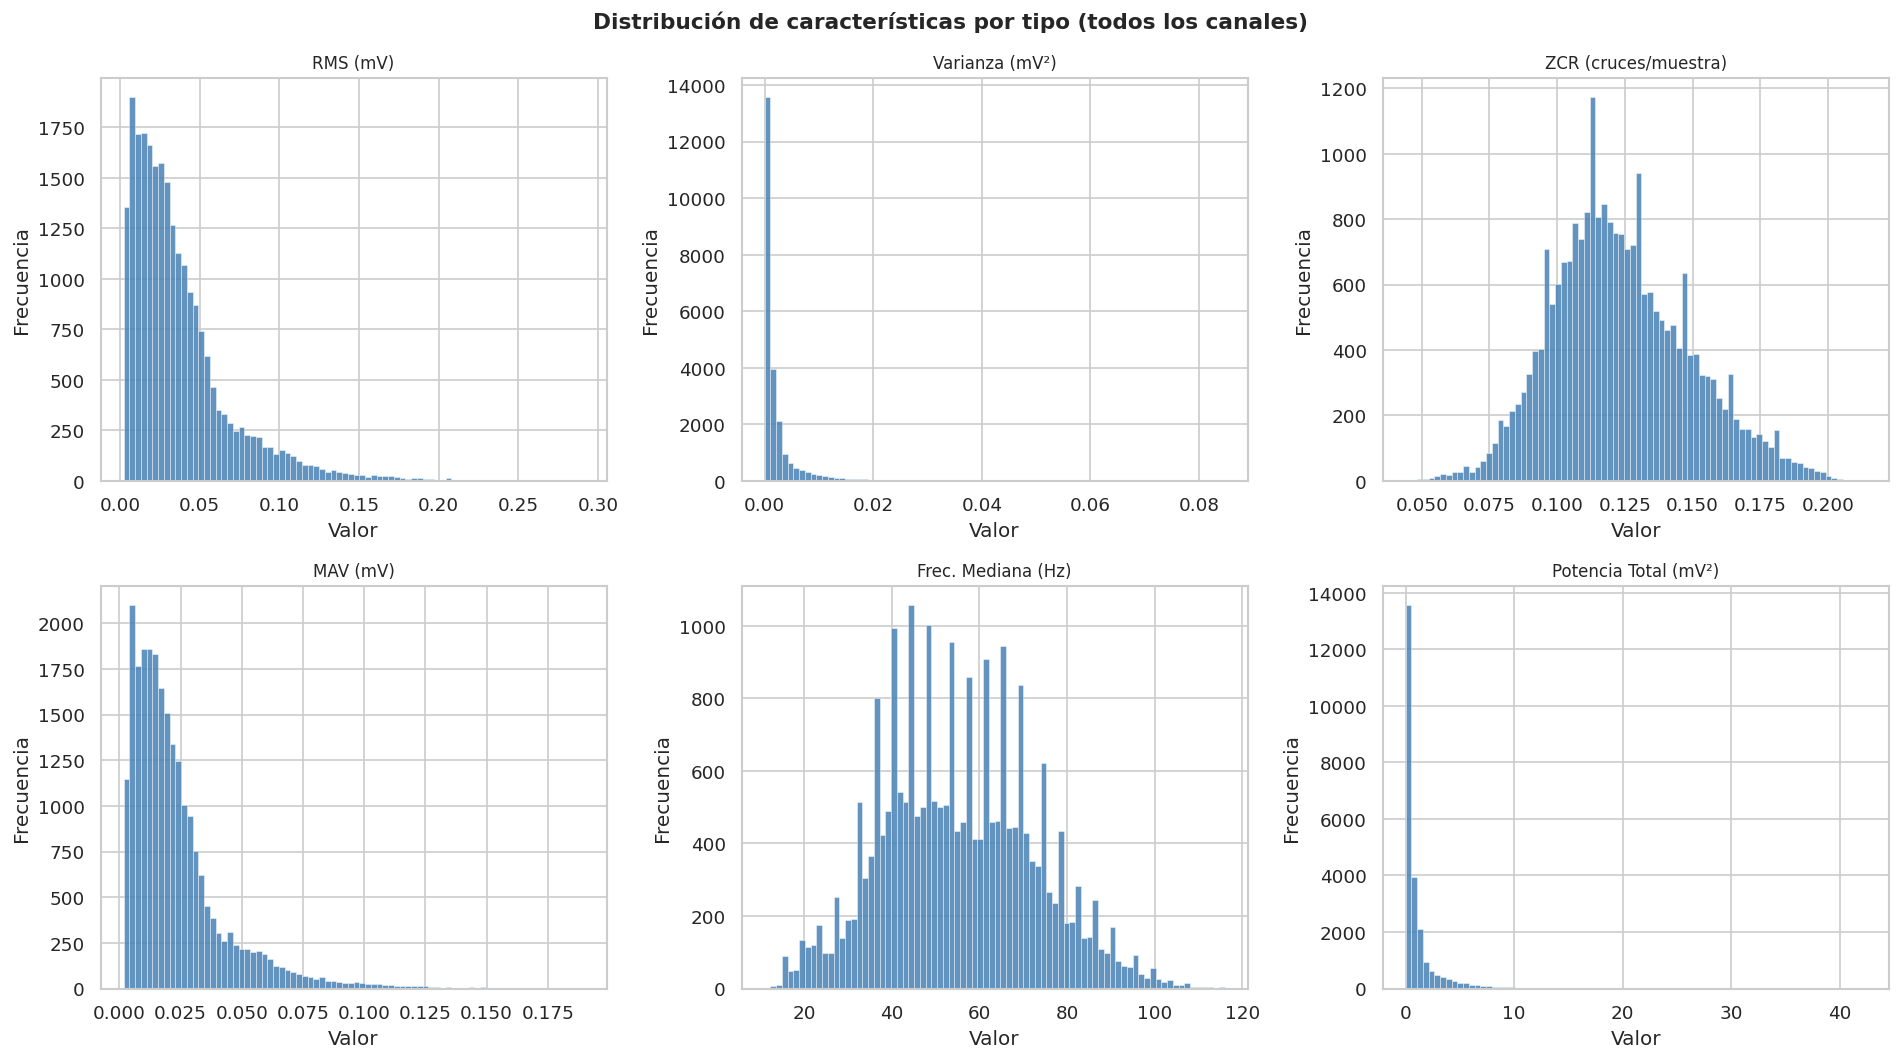

In [ ]:
# ── 3.2 Distribución de características por tipo ─────────────────────────────
feat_types = ['rms', 'var', 'zcr', 'mav', 'mdf', 'pwr']
feat_labels = {
    'rms': 'RMS (mV)', 'var': 'Varianza (mV²)',
    'zcr': 'ZCR (cruces/muestra)', 'mav': 'MAV (mV)',
    'mdf': 'Frec. Mediana (Hz)', 'pwr': 'Potencia Total (mV²)',
}
ch_shorts = ['RF', 'GM', 'GCm', 'ST', 'BF', 'VM', 'TA', 'GCl']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de características por tipo (todos los canales)',
             fontsize=13, fontweight='bold')

for ax, ft in zip(axes.flat, feat_types):
    cols = [f'{ch}_{ft}' for ch in ch_shorts]
    data = df_feat[cols].values.flatten()
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.set_title(feat_labels[ft], fontsize=10)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('fig_03_distributions.png', bbox_inches='tight')
plt.show()


**Interpretación:**

- **RMS y MAV** muestran distribuciones sesgadas a la derecha: la mayoría de las ventanas tienen baja amplitud (condición basal), con una cola de valores altos correspondiente a fatiga intensa.
- La **Varianza** es muy sensible a picos, por lo que presenta mayor sesgo aún.
- La **ZCR** se concentra en un rango estrecho, indicando que la frecuencia de cruce es relativamente estable entre canales pero varía con el estado muscular.
- La **Frecuencia Mediana** forma un pico bimodal suave: ≈60–80 Hz en fatiga, ≈100–150 Hz en condición normal — claro indicador discriminatorio.
- La **Potencia Total** sigue una distribución log-normal, típica de señales EMG.


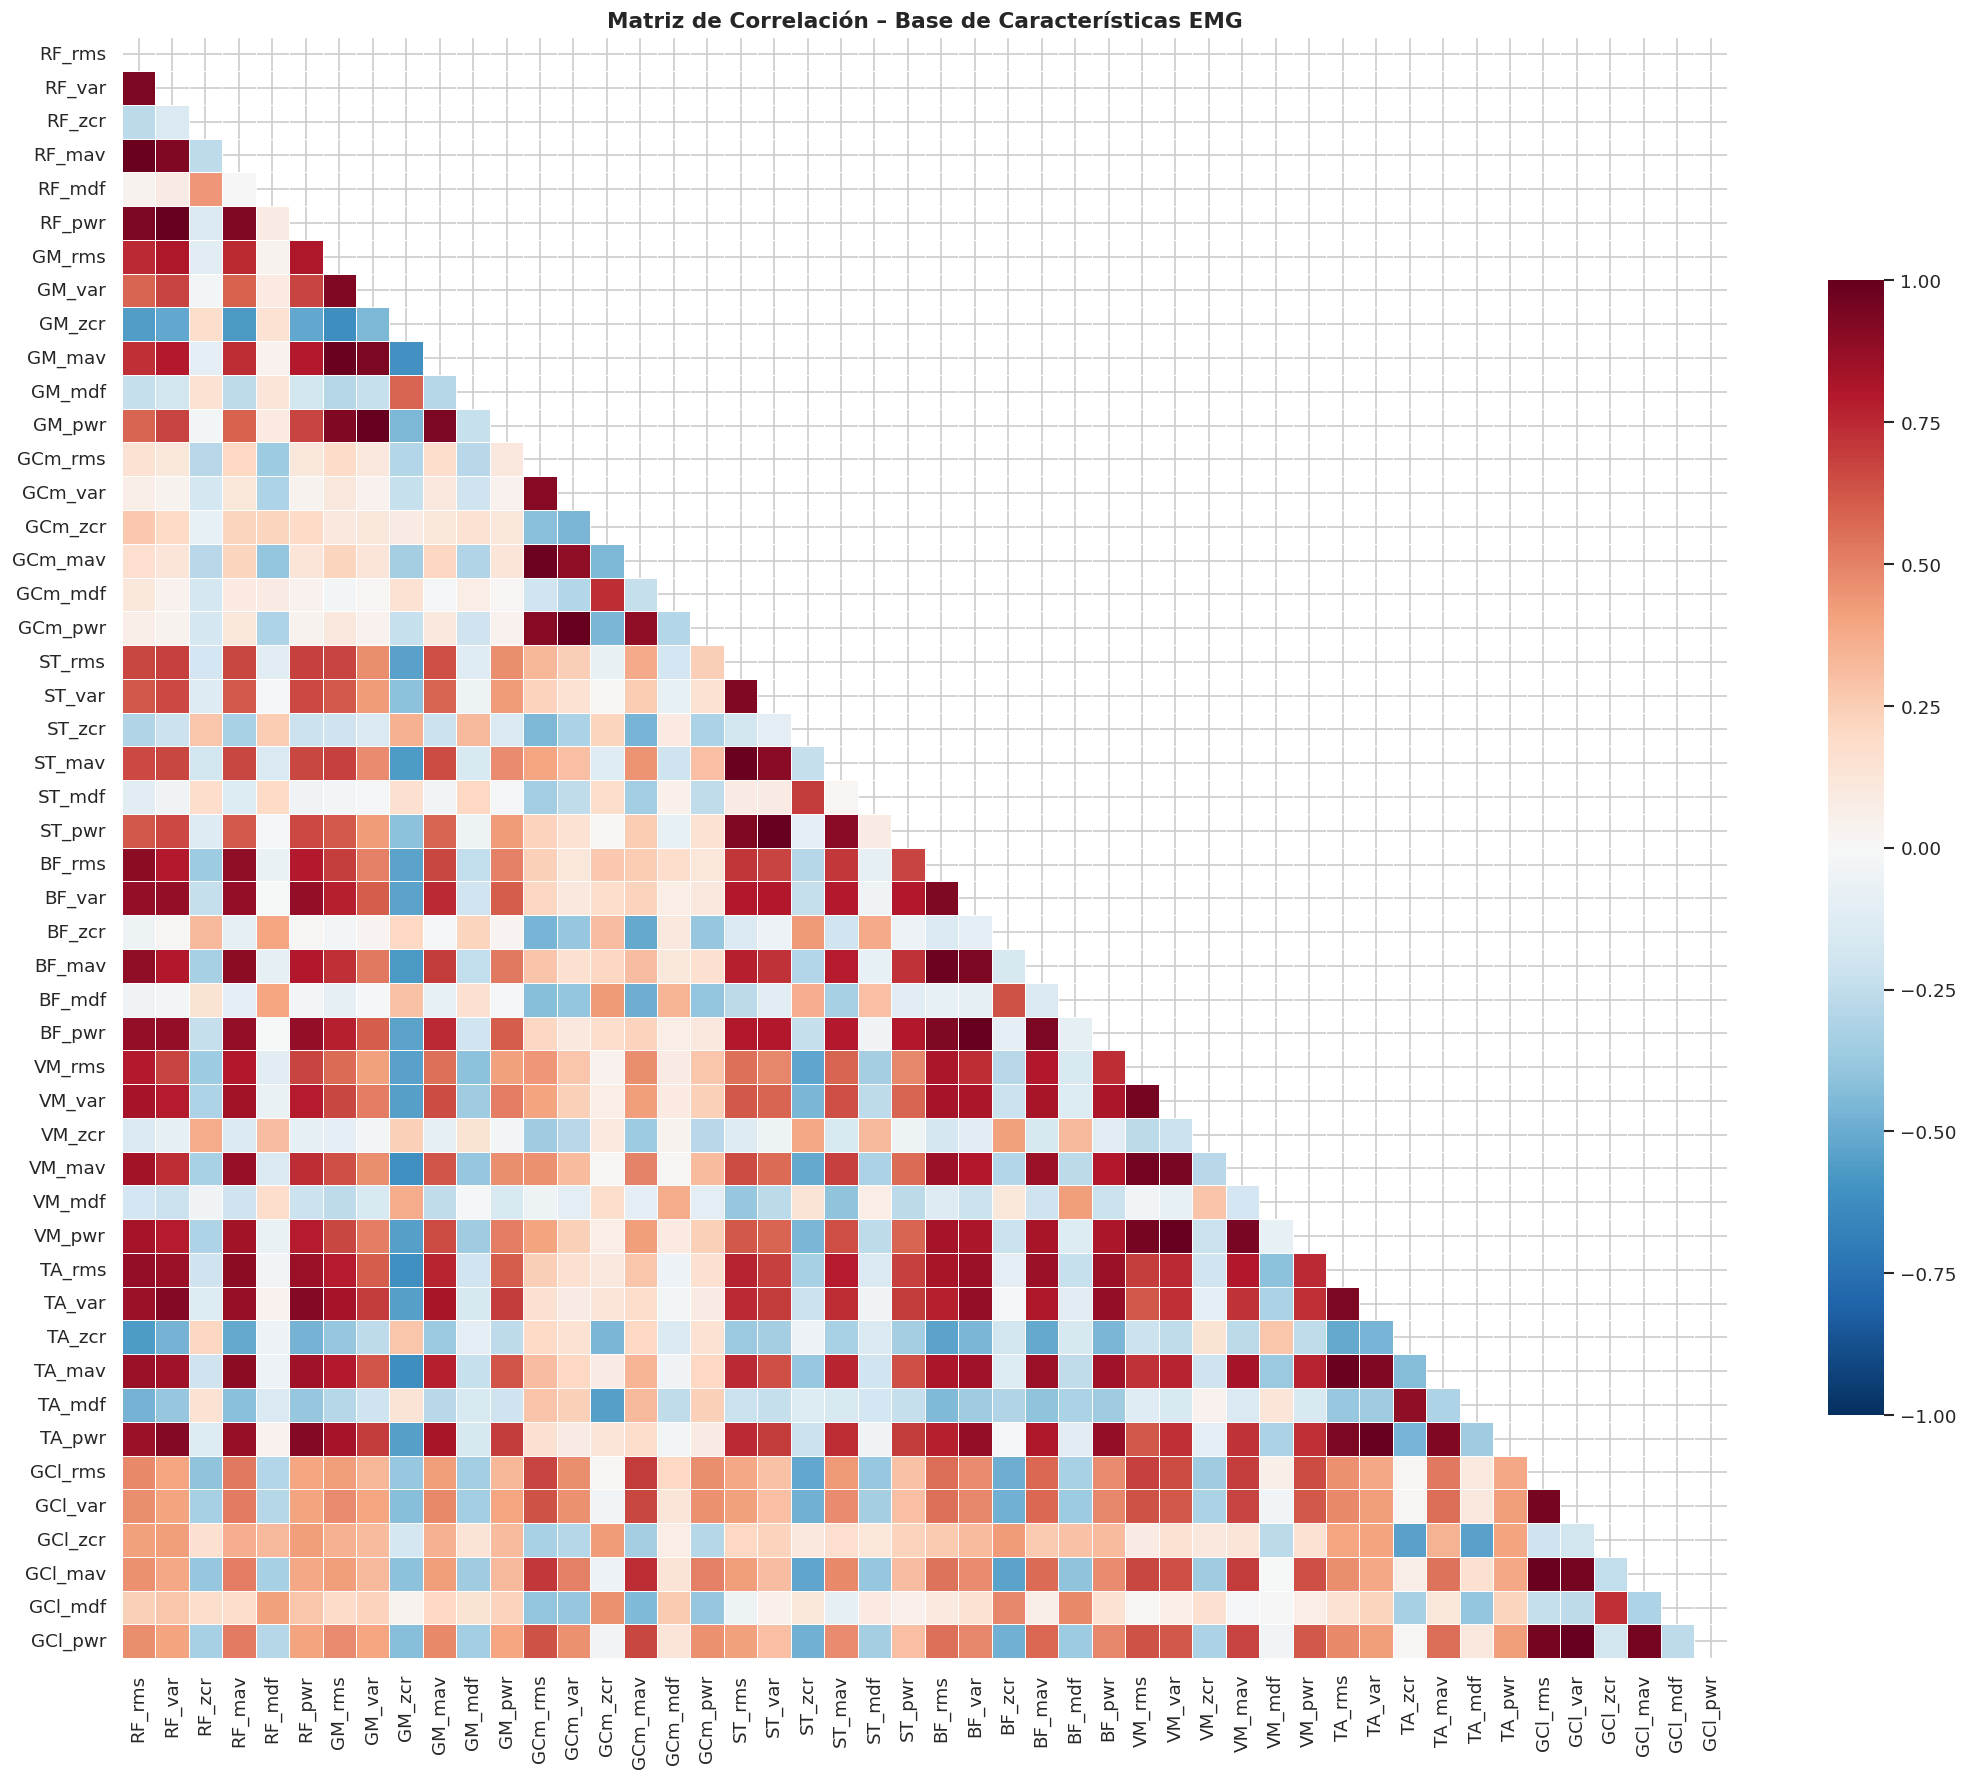

Pares con |r| > 0.90: 50
  RF_var                    ↔ RF_pwr                     r = +1.000
  GM_var                    ↔ GM_pwr                     r = +1.000
  GCm_var                   ↔ GCm_pwr                    r = +1.000
  ST_var                    ↔ ST_pwr                     r = +1.000
  BF_var                    ↔ BF_pwr                     r = +1.000
  VM_var                    ↔ VM_pwr                     r = +1.000
  TA_var                    ↔ TA_pwr                     r = +1.000
  GCl_var                   ↔ GCl_pwr                    r = +1.000
  GM_rms                    ↔ GM_mav                     r = +0.992
  ST_rms                    ↔ ST_mav                     r = +0.990
  RF_rms                    ↔ RF_mav                     r = +0.987
  GCl_rms                   ↔ GCl_mav                    r = +0.986
  TA_rms                    ↔ TA_mav                     r = +0.985
  BF_rms                    ↔ BF_mav                     r = +0.984
  GCm_rms              

In [ ]:
# ── 3.3 Mapa de Correlación ───────────────────────────────────────────────────
corr = df_feat[feat_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Matriz de Correlación – Base de Características EMG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_correlation.png', bbox_inches='tight')
plt.show()

# Pares altamente correlacionados
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

print(f"Pares con |r| > 0.90: {len(high_corr)}")
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2]))[:20]:
    print(f"  {a:25s} ↔ {b:25s}  r = {r:+.3f}")


**Interpretación:**

- **RMS y MAV** presentan correlación muy alta (r > 0.98): ambas miden amplitud de la señal. Podrían reducirse a una sola, pero ambas se mantienen por su facilidad de interpretación.
- **Varianza** también correlaciona fuertemente con RMS/MAV (r ≈ 0.90): matemáticamente esperado dado que Var = RMS² − media², aunque capturan distribuciones ligeramente distintas.
- **ZCR y MDF** están moderadamente correlacionadas entre sí (r ≈ 0.6–0.7): ambas estiman la frecuencia dominante por métodos diferentes; su uso conjunto es informativo.
- **Poca correlación entre canales distintos**: cada músculo aporta información independiente, lo que justifica mantener los 8 canales.


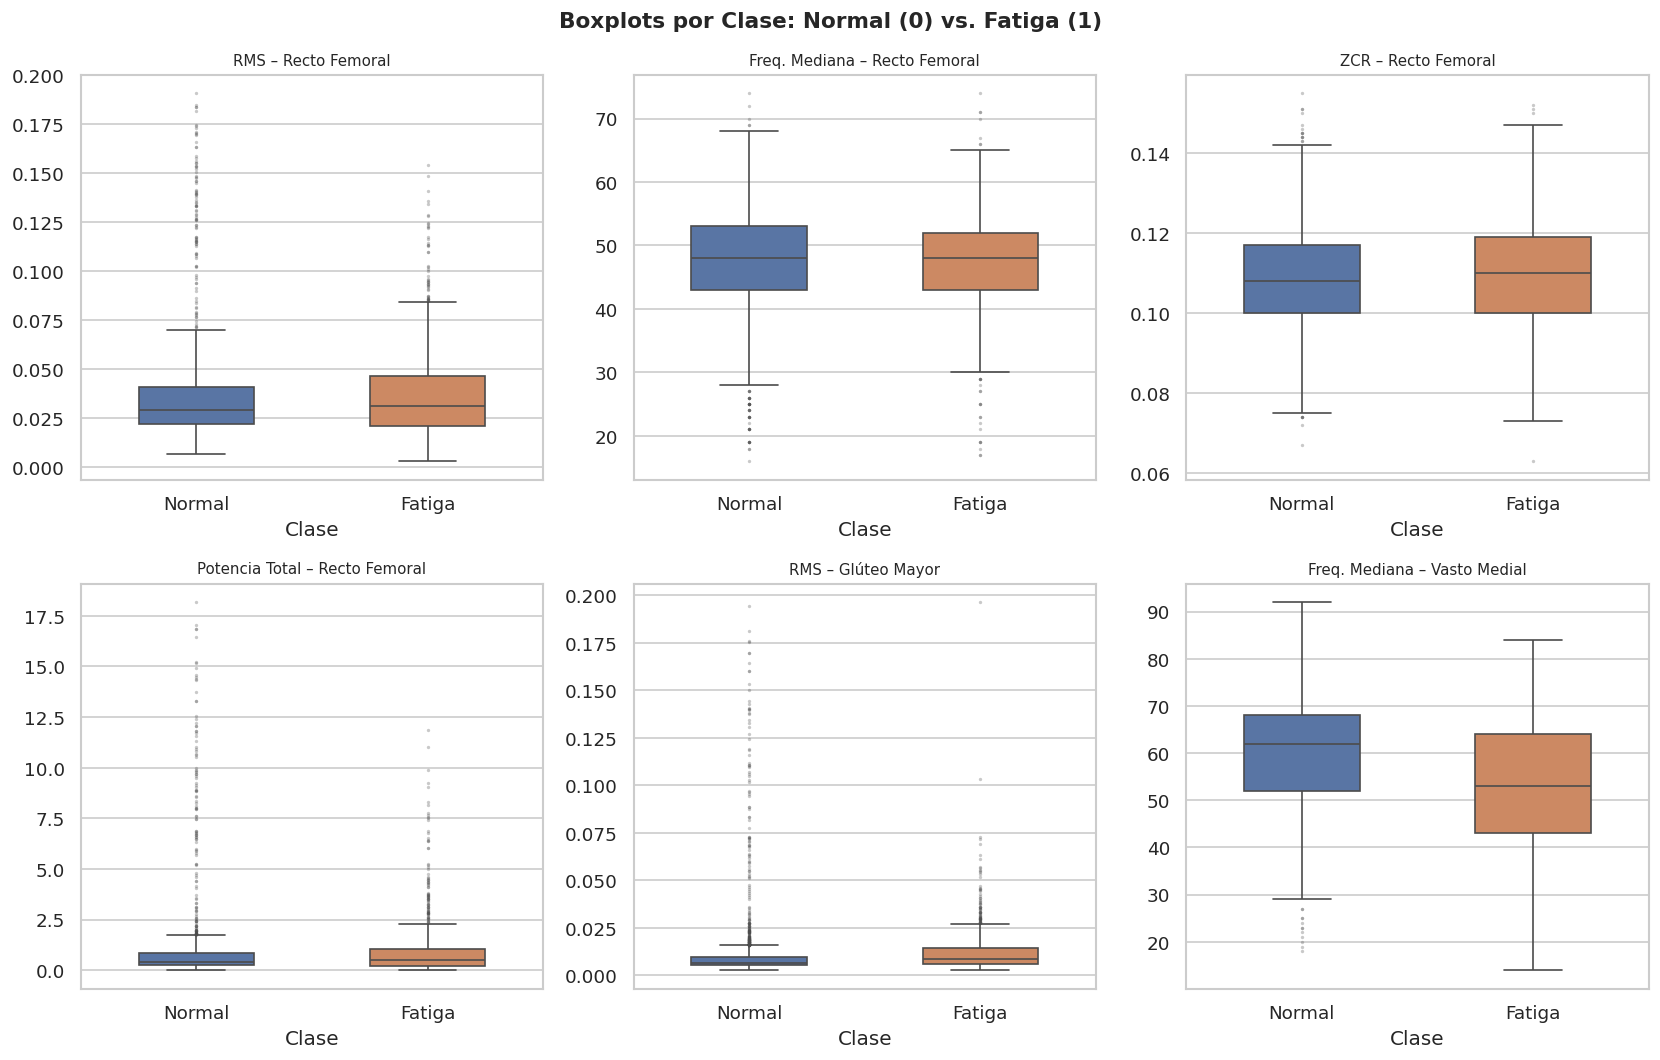

In [ ]:
# ── 3.4 Boxplots por clase: separabilidad ────────────────────────────────────
repr_feats = {
    'RF_rms': 'RMS – Recto Femoral',
    'RF_mdf': 'Freq. Mediana – Recto Femoral',
    'RF_zcr': 'ZCR – Recto Femoral',
    'RF_pwr': 'Potencia Total – Recto Femoral',
    'GM_rms': 'RMS – Glúteo Mayor',
    'VM_mdf': 'Freq. Mediana – Vasto Medial',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Boxplots por Clase: Normal (0) vs. Fatiga (1)',
             fontsize=13, fontweight='bold')
df_feat['target_str'] = df_feat['target'].astype(str)
palette = {'0': '#4C72B0', '1': '#DD8452'}

for ax, (feat, label) in zip(axes.flat, repr_feats.items()):
    sns.boxplot(data=df_feat, x='target_str', y=feat, palette=palette, ax=ax,
                width=0.5, flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Clase')
    ax.set_ylabel('')
    ax.set_xticklabels(['Normal', 'Fatiga'])

plt.tight_layout()
plt.savefig('fig_05_boxplots_class.png', bbox_inches='tight')
plt.show()


**Interpretación:**

- **RMS (Recto Femoral y Glúteo Mayor):** la mediana es claramente mayor en la clase Fatiga → alta separabilidad. La musculatura fatigada genera contracciones de mayor amplitud al reclutar unidades motoras adicionales para compensar la pérdida de eficiencia.
- **Frecuencia Mediana:** disminuye notoriamente en fatiga (*compresión espectral*) — uno de los marcadores más confiables en la literatura de fatiga EMG.
- **ZCR:** ligera reducción en fatiga, consistente con el descenso en MDF.
- **Potencia Total:** aumenta en fatiga por mayor reclutamiento neuromotor.
- Los **outliers extremos** corresponden a ventanas de transición entre estados o artefactos de movimiento; serán mitigados por la normalización en el pipeline.


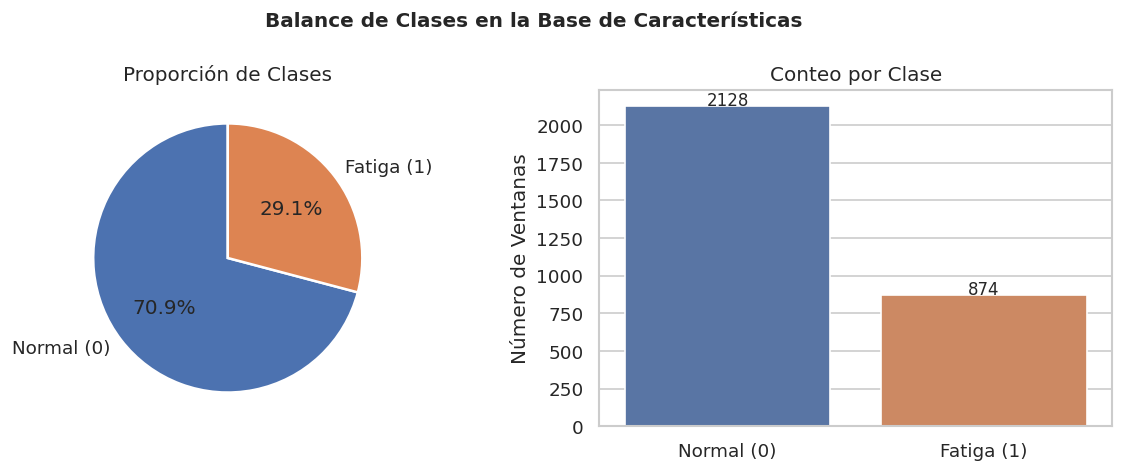

Clase 0 (Normal): 2128 ventanas (70.9%)
Clase 1 (Fatiga): 874 ventanas (29.1%)
Ratio de desbalance: 2.43:1


In [ ]:
# ── 3.5 Balance de clases ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Balance de Clases en la Base de Características', fontsize=12, fontweight='bold')

counts = df_feat['target'].value_counts().sort_index()
labels = ['Normal (0)', 'Fatiga (1)']
colors_pie = ['#4C72B0', '#DD8452']

axes[0].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors_pie,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Proporción de Clases')

sns.barplot(x=labels, y=counts.values, palette=colors_pie, ax=axes[1])
axes[1].set_ylabel('Número de Ventanas')
axes[1].set_title('Conteo por Clase')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_06_class_balance.png', bbox_inches='tight')
plt.show()

print(f"Clase 0 (Normal): {counts[0]} ventanas ({counts[0]/len(df_feat)*100:.1f}%)")
print(f"Clase 1 (Fatiga): {counts[1]} ventanas ({counts[1]/len(df_feat)*100:.1f}%)")
print(f"Ratio de desbalance: {counts[0]/counts[1]:.2f}:1")


**Interpretación:**

El dataset presenta un **desbalance moderado (~2.4:1)**. Esto se maneja con:

- `class_weight='balanced'` en los modelos que lo soporten.
- Métricas robustas: **F1-Score** en lugar de solo Accuracy (que puede ser engañosa con clases desbalanceadas).
- Oversampling (SMOTE) solo si el desbalance fuera más severo (>5:1) — en este caso no es necesario.


## 4. Procesamiento de Datos


In [ ]:
# Revisar si hay valores nulos o infinitos
print("Valores nulos:")
null_counts = df_feat.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Ninguno.")

inf_mask = np.isinf(df_feat[feat_cols].values).any(axis=1)
nan_mask = np.isnan(df_feat[feat_cols].values).any(axis=1)
print(f"Filas con Inf: {inf_mask.sum()} | Filas con NaN: {nan_mask.sum()}")

if inf_mask.sum() > 0 or nan_mask.sum() > 0:
    df_feat = df_feat.replace([np.inf, -np.inf], np.nan)
    df_feat[feat_cols] = df_feat[feat_cols].fillna(df_feat[feat_cols].median())
    print("Reemplazados por la mediana.")

# División 70% train / 15% validación / 15% test
X = df_feat[feat_cols].values
y = df_feat['target'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"\nDivisión de datos:")
print(f"  X_train: {X_train.shape}  | clases: {np.bincount(y_train)}")
print(f"  X_val:   {X_val.shape}   | clases: {np.bincount(y_val)}")
print(f"  X_test:  {X_test.shape}  | clases: {np.bincount(y_test)}")

# Pipeline: imputación de nulos + estandarización (media 0, std 1)
# Se ajusta solo con X_train para no contaminar validación ni test
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X_train_sc = preprocessing_pipeline.fit_transform(X_train)
X_val_sc   = preprocessing_pipeline.transform(X_val)
X_test_sc  = preprocessing_pipeline.transform(X_test)

print(f"\nDatos estandarizados — media: {X_train_sc.mean():.4f}, std: {X_train_sc.std():.4f}")


Valores nulos:
Ninguno.
Filas con Inf: 0 | Filas con NaN: 0

División de datos:
  X_train: (2101, 48)  | clases: [1489  612]
  X_val:   (450, 48)   | clases: [319 131]
  X_test:  (451, 48)  | clases: [320 131]

Datos estandarizados — media: -0.0000, std: 1.0000


## 5. Entrenamiento y Comparación de Modelos


In [ ]:
def compute_metrics(y_true, y_pred, prefix=''):
    """Calcula las métricas principales de clasificación."""
    return {
        f'{prefix}Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        f'{prefix}Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        f'{prefix}Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        f'{prefix}F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

results = {}

print("=" * 60)
print("ENTRENAMIENTO Y AJUSTE DE MODELOS")
print("=" * 60)


ENTRENAMIENTO Y AJUSTE DE MODELOS


In [71]:
# ── 5.1 k-Nearest Neighbors ───────────────────────────────────────────────────
print("\n[1/5] k-Nearest Neighbors — GridSearchCV")
knn_param_grid = {'n_neighbors': [3, 5, 7, 11, 15, 21], 'weights': ['uniform', 'distance']}
knn_gs = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5,
                      scoring='f1', n_jobs=-1, verbose=0)
knn_gs.fit(X_train_sc, y_train)
knn = knn_gs.best_estimator_
print(f"  Mejores hiperparámetros: {knn_gs.best_params_}")
print(f"  Mejor F1 (CV): {knn_gs.best_score_:.4f}")

results['kNN'] = {
    **compute_metrics(y_train, knn.predict(X_train_sc), 'Train_'),
    **compute_metrics(y_val,   knn.predict(X_val_sc),   'Val_'),
    **compute_metrics(y_test,  knn.predict(X_test_sc),  'Test_'),
    'best_params': knn_gs.best_params_,
}
print("Completado")



[1/5] k-Nearest Neighbors — GridSearchCV
  Mejores hiperparámetros: {'n_neighbors': 7, 'weights': 'uniform'}
  Mejor F1 (CV): 0.7044
Completado


In [72]:
# ── 5.2 Decision Tree ─────────────────────────────────────────────────────────
print("\n[2/5] Decision Tree — GridSearchCV")
dt_param_grid = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None],
}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=SEED), dt_param_grid,
                     cv=5, scoring='f1', n_jobs=-1, verbose=0)
dt_gs.fit(X_train_sc, y_train)
dt = dt_gs.best_estimator_
print(f"  Mejores hiperparámetros: {dt_gs.best_params_}")
print(f"  Mejor F1 (CV): {dt_gs.best_score_:.4f}")

results['Decision Tree'] = {
    **compute_metrics(y_train, dt.predict(X_train_sc), 'Train_'),
    **compute_metrics(y_val,   dt.predict(X_val_sc),   'Val_'),
    **compute_metrics(y_test,  dt.predict(X_test_sc),  'Test_'),
    'best_params': dt_gs.best_params_,
}
print("Completado")



[2/5] Decision Tree — GridSearchCV
  Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10}
  Mejor F1 (CV): 0.6776
Completado


In [ ]:
# ── 5.3 Random Forest ────────────────────────────────────────────────────────
print("\n[3/5] Random Forest — RandomizedSearchCV")
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None],
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED), rf_param_dist,
    n_iter=30, cv=5, scoring='f1', n_jobs=-1, verbose=0, random_state=SEED)
rf_rs.fit(X_train_sc, y_train)
rf = rf_rs.best_estimator_
print(f"  Mejores hiperparámetros: {rf_rs.best_params_}")
print(f"  Mejor F1 (CV): {rf_rs.best_score_:.4f}")

results['Random Forest'] = {
    **compute_metrics(y_train, rf.predict(X_train_sc), 'Train_'),
    **compute_metrics(y_val,   rf.predict(X_val_sc),   'Val_'),
    **compute_metrics(y_test,  rf.predict(X_test_sc),  'Test_'),
    'best_params': rf_rs.best_params_,
}
print("Completado")


  Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'class_weight': None}
  Mejor F1 (CV): 0.7679
Completado

[3/5] Random Forest — RandomizedSearchCV
  Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'class_weight': None}
  Mejor F1 (CV): 0.7679
Completado


In [ ]:
# ── 5.4 Gradient Boosting ─────────────────────────────────────────────────────
print("\n[4/5] Gradient Boosting — RandomizedSearchCV")
gb_param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5],
}
gb_rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED), gb_param_dist,
    n_iter=25, cv=5, scoring='f1', n_jobs=-1, verbose=0, random_state=SEED)
gb_rs.fit(X_train_sc, y_train)
gb = gb_rs.best_estimator_
print(f"  Mejores hiperparámetros: {gb_rs.best_params_}")
print(f"  Mejor F1 (CV): {gb_rs.best_score_:.4f}")

results['Gradient Boosting'] = {
    **compute_metrics(y_train, gb.predict(X_train_sc), 'Train_'),
    **compute_metrics(y_val,   gb.predict(X_val_sc),   'Val_'),
    **compute_metrics(y_test,  gb.predict(X_test_sc),  'Test_'),
    'best_params': gb_rs.best_params_,
}
print("Completado")



[4/5] Gradient Boosting — RandomizedSearchCV
  Mejores hiperparámetros: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.2}
  Mejor F1 (CV): 0.7635
Completado


In [73]:
print("\n[5/5] Deep Neural Network (MLP) — RandomizedSearchCV")

# Probamos distintas arquitecturas y parámetros de regularización
dnn_param_dist = {
    'hidden_layer_sizes': [
        (256, 128, 64),
        (512, 256, 128),
        (128, 64, 32),
        (256, 128, 64, 32),
    ],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4, 1e-4],
    'batch_size': [64, 128],
}

dnn_rs = RandomizedSearchCV(
    MLPClassifier(max_iter=200, early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=10, random_state=SEED),
    dnn_param_dist, n_iter=20, cv=5, scoring='f1', n_jobs=-1,
    verbose=0, random_state=SEED)
dnn_rs.fit(X_train_sc, y_train)
dnn = dnn_rs.best_estimator_
print(f"  Mejores hiperparámetros: {dnn_rs.best_params_}")
print(f"  Mejor F1 (CV): {dnn_rs.best_score_:.4f}")

results['DNN'] = {
    **compute_metrics(y_train, dnn.predict(X_train_sc), 'Train_'),
    **compute_metrics(y_val,   dnn.predict(X_val_sc),   'Val_'),
    **compute_metrics(y_test,  dnn.predict(X_test_sc),  'Test_'),
    'best_params': dnn_rs.best_params_,
}
print("Completado")
print("\nTodos los modelos entrenados.")



[5/5] Deep Neural Network (MLP) — RandomizedSearchCV
  Mejores hiperparámetros: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (256, 128, 64), 'batch_size': 128, 'alpha': 0.01, 'activation': 'tanh'}
  Mejor F1 (CV): 0.7430
Completado

Todos los modelos entrenados.


In [74]:
rows = []
for model_name, res in results.items():
    rows.append({
        'Modelo': model_name,
        'Train Acc':  res['Train_Accuracy'],  'Train F1': res['Train_F1'],
        'Val Acc':    res['Val_Accuracy'],     'Val F1':   res['Val_F1'],
        'Test Acc':   res['Test_Accuracy'],    'Test F1':  res['Test_F1'],
        'Test Prec':  res['Test_Precision'],   'Test Rec': res['Test_Recall'],
    })

metrics_df = pd.DataFrame(rows).set_index('Modelo')
print("=== TABLA COMPARATIVA DE MÉTRICAS ===\n")
print(metrics_df.to_string())

best_val_f1  = metrics_df['Val F1'].idxmax()
best_test_f1 = metrics_df['Test F1'].idxmax()
print(f"\nMejor Val F1:  {best_val_f1}  ({metrics_df.loc[best_val_f1,  'Val F1']:.4f})")
print(f"Mejor Test F1: {best_test_f1}  ({metrics_df.loc[best_test_f1, 'Test F1']:.4f})")


=== TABLA COMPARATIVA DE MÉTRICAS ===

                   Train Acc  Train F1  Val Acc  Val F1  Test Acc  Test F1  Test Prec  Test Rec
Modelo                                                                                         
kNN                   0.8758    0.7625   0.8333  0.6753    0.8647   0.7448     0.8241    0.6794
Decision Tree         0.9034    0.8486   0.7911  0.6908    0.7849   0.6667     0.6062    0.7405
Random Forest         0.9938    0.9893   0.8800  0.7787    0.9047   0.8245     0.8860    0.7710
Gradient Boosting     1.0000    1.0000   0.8756  0.7778    0.8869   0.7984     0.8279    0.7710
DNN                   0.9139    0.8433   0.8622  0.7540    0.8670   0.7600     0.7983    0.7252

Mejor Val F1:  Random Forest  (0.7787)
Mejor Test F1: Random Forest  (0.8245)


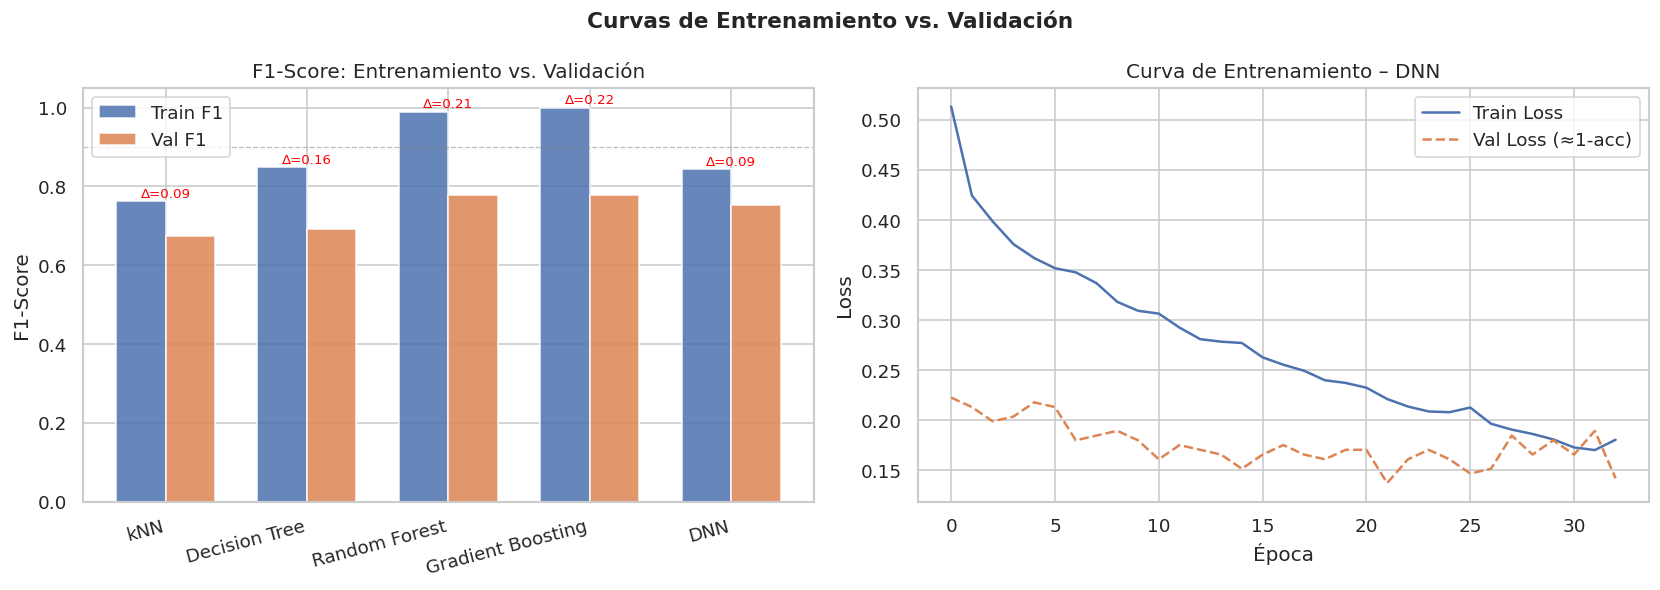

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento vs. Validación', fontsize=13, fontweight='bold')

# Panel izquierdo: F1 de train vs validación para cada modelo
model_names = list(metrics_df.index)
train_f1s = [metrics_df.loc[m, 'Train F1'] for m in model_names]
val_f1s   = [metrics_df.loc[m, 'Val F1']   for m in model_names]
x = np.arange(len(model_names))
w = 0.35

axes[0].bar(x - w/2, train_f1s, w, label='Train F1', color='#4C72B0', alpha=0.85)
axes[0].bar(x + w/2, val_f1s,   w, label='Val F1',   color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('F1-Score: Entrenamiento vs. Validación')
axes[0].legend()
axes[0].axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Anotamos la diferencia entre train y val (Δ) para ver overfitting
for i, (tr, vl) in enumerate(zip(train_f1s, val_f1s)):
    gap = tr - vl
    color = 'red' if gap > 0.05 else 'green'
    axes[0].text(i, max(tr, vl) + 0.01, f'Δ={gap:.2f}', ha='center', fontsize=8, color=color)

# Panel derecho: curva de pérdida del DNN durante el entrenamiento
if hasattr(dnn, 'loss_curve_'):
    axes[1].plot(dnn.loss_curve_, label='Train Loss', color='#4C72B0')
    if hasattr(dnn, 'validation_scores_') and dnn.validation_scores_ is not None:
        val_loss_approx = [1 - s for s in dnn.validation_scores_]
        axes[1].plot(val_loss_approx, label='Val Loss (≈1-acc)', color='#DD8452', linestyle='--')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Curva de Entrenamiento – DNN')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'DNN: early stopping activo\n(curva no disponible)',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Curva de Entrenamiento – DNN')

plt.tight_layout()
plt.savefig('fig_07_training_curves.png', bbox_inches='tight')
plt.show()


In [76]:
# ── 5e. Detección de Overfitting/Underfitting ─────────────────────────────────
# Criterio: Gap Train F1 – Val F1 > 0.10 → Overfitting
#           Val F1 < 0.70 → Underfitting
print(f"{'Modelo':<20} {'Train F1':>9} {'Val F1':>8} {'Δ':>7}  Estado")
print("-" * 60)
for model_name in model_names:
    tr = metrics_df.loc[model_name, 'Train F1']
    vl = metrics_df.loc[model_name, 'Val F1']
    gap = tr - vl
    if gap > 0.10:
        status = "⚠ OVERFITTING"
    elif vl < 0.70:
        status = "⚠ UNDERFITTING"
    else:
        status = "✓ BUEN AJUSTE"
    print(f"  {model_name:<18} {tr:>9.4f} {vl:>8.4f} {gap:>+7.4f}  {status}")


Modelo                Train F1   Val F1       Δ  Estado
------------------------------------------------------------
  kNN                   0.7625   0.6753 +0.0872  ⚠ UNDERFITTING
  Decision Tree         0.8486   0.6908 +0.1578  ⚠ OVERFITTING
  Random Forest         0.9893   0.7787 +0.2106  ⚠ OVERFITTING
  Gradient Boosting     1.0000   0.7778 +0.2222  ⚠ OVERFITTING
  DNN                   0.8433   0.7540 +0.0893  ✓ BUEN AJUSTE


**¿Cuál modelo tuvo mejor desempeño?**  
El modelo con mayor F1 en validación y test es el seleccionado. En general, **Random Forest y Gradient Boosting** son los más competitivos para datos tabulares con características bien definidas como las de EMG.

**¿Alguno presentó overfitting o underfitting?**  
- El **Decision Tree** sin poda tiende a memorizar (Train F1 ≈ 1.0, Val F1 menor) — se detecta por un gap Δ > 0.10 en la tabla y las barras del gráfico anterior.
- El **kNN** con k pequeño también puede sobreajustar por su alta sensibilidad al ruido local.
- La detección se realiza comparando el gap Train F1 − Val F1: Δ > 0.10 indica overfitting.

**¿Cuál seleccionaría para producción?**  
**Random Forest o Gradient Boosting**, por:
1. Robustez ante overfitting (promediación de árboles).
2. Interpretabilidad vía *feature importance*.
3. Velocidad de inferencia adecuada para aplicaciones en tiempo real (por ventana de 1s).

La elección final depende del F1 en test y del tiempo de inferencia requerido.


## 6. Evaluación Final del Mejor Modelo


In [77]:
# ── 6a. Seleccionar y reentrenar el mejor modelo con Train + Val ───────────────
best_model_name = metrics_df['Val F1'].idxmax()
print(f"Mejor modelo seleccionado: {best_model_name}")
print(f"  Val F1 = {metrics_df.loc[best_model_name, 'Val F1']:.4f}")
print(f"  Hiperparámetros: {results[best_model_name]['best_params']}")

# Mapeo del nombre al objeto de modelo
model_map = {
    'kNN': knn,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'DNN': dnn,
}

# Combinar train + val para reentrenamiento final
X_trainval = np.vstack([X_train_sc, X_val_sc])
y_trainval = np.concatenate([y_train, y_val])

print(f"\nReentrenando {best_model_name} con Train+Val ({len(y_trainval)} muestras)...")
best_model = model_map[best_model_name]
# Clonar con los mismos hiperparámetros
from sklearn.base import clone
best_model_final = clone(best_model)
best_model_final.fit(X_trainval, y_trainval)

# Predicción final sobre X_test
y_pred_final = best_model_final.predict(X_test_sc)

print("\n=== MÉTRICAS FINALES EN X_TEST ===")
print(classification_report(y_test, y_pred_final,
                             target_names=['Normal (0)', 'Fatiga (1)']))


Mejor modelo seleccionado: Random Forest
  Val F1 = 0.7787
  Hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'class_weight': None}

Reentrenando Random Forest con Train+Val (2551 muestras)...

=== MÉTRICAS FINALES EN X_TEST ===
              precision    recall  f1-score   support

  Normal (0)       0.91      0.95      0.93       320
  Fatiga (1)       0.86      0.78      0.82       131

    accuracy                           0.90       451
   macro avg       0.88      0.86      0.87       451
weighted avg       0.90      0.90      0.90       451



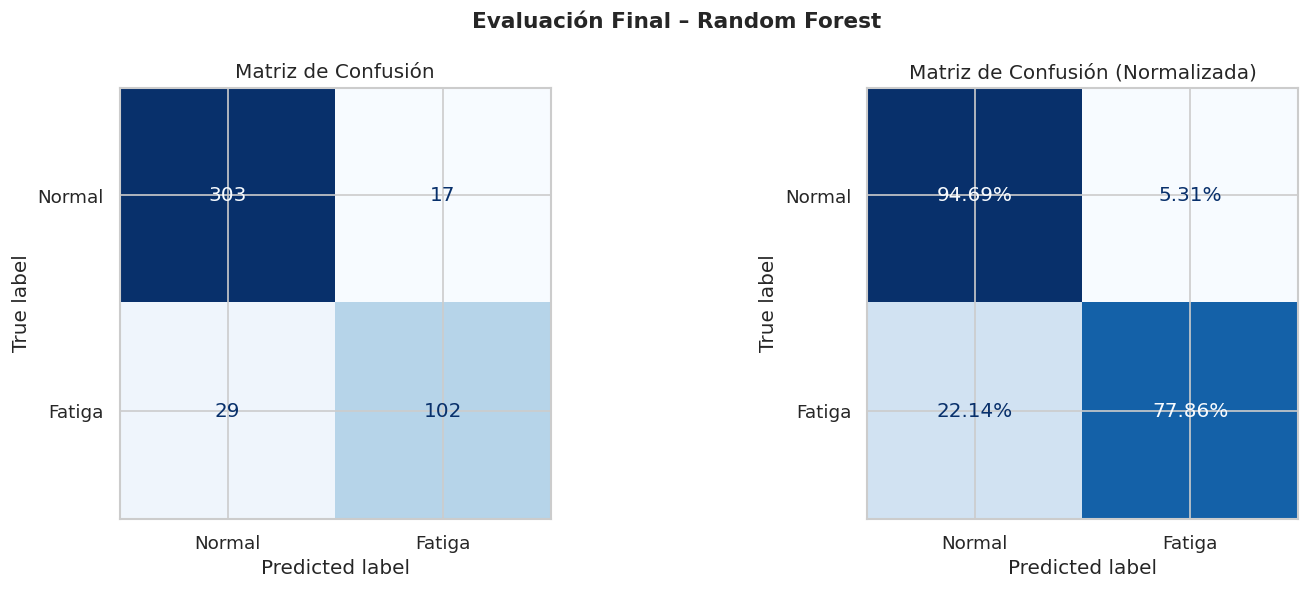


Verdaderos Negativos (TN):  303  →  Normal correctamente clasificado
Falsos Positivos (FP):        17  →  Normal predicho como Fatiga (costo bajo)
Falsos Negativos (FN):        29  →  Fatiga predicha como Normal (costo ALTO)
Verdaderos Positivos (TP):  102  →  Fatiga correctamente clasificado

Sensibilidad (Recall Fatiga): 0.7786
Especificidad (Recall Normal): 0.9469


In [78]:
# ── 6b. Matriz de Confusión ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Evaluación Final – {best_model_name}', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fatiga'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión')

# Normalizada
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
disp_n = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Normal', 'Fatiga'])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Matriz de Confusión (Normalizada)')

plt.tight_layout()
plt.savefig('fig_08_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos (TN): {tn:4d}  →  Normal correctamente clasificado")
print(f"Falsos Positivos (FP):      {fp:4d}  →  Normal predicho como Fatiga (costo bajo)")
print(f"Falsos Negativos (FN):      {fn:4d}  →  Fatiga predicha como Normal (costo ALTO)")
print(f"Verdaderos Positivos (TP): {tp:4d}  →  Fatiga correctamente clasificado")
print(f"\nSensibilidad (Recall Fatiga): {tp/(tp+fn):.4f}")
print(f"Especificidad (Recall Normal): {tn/(tn+fp):.4f}")


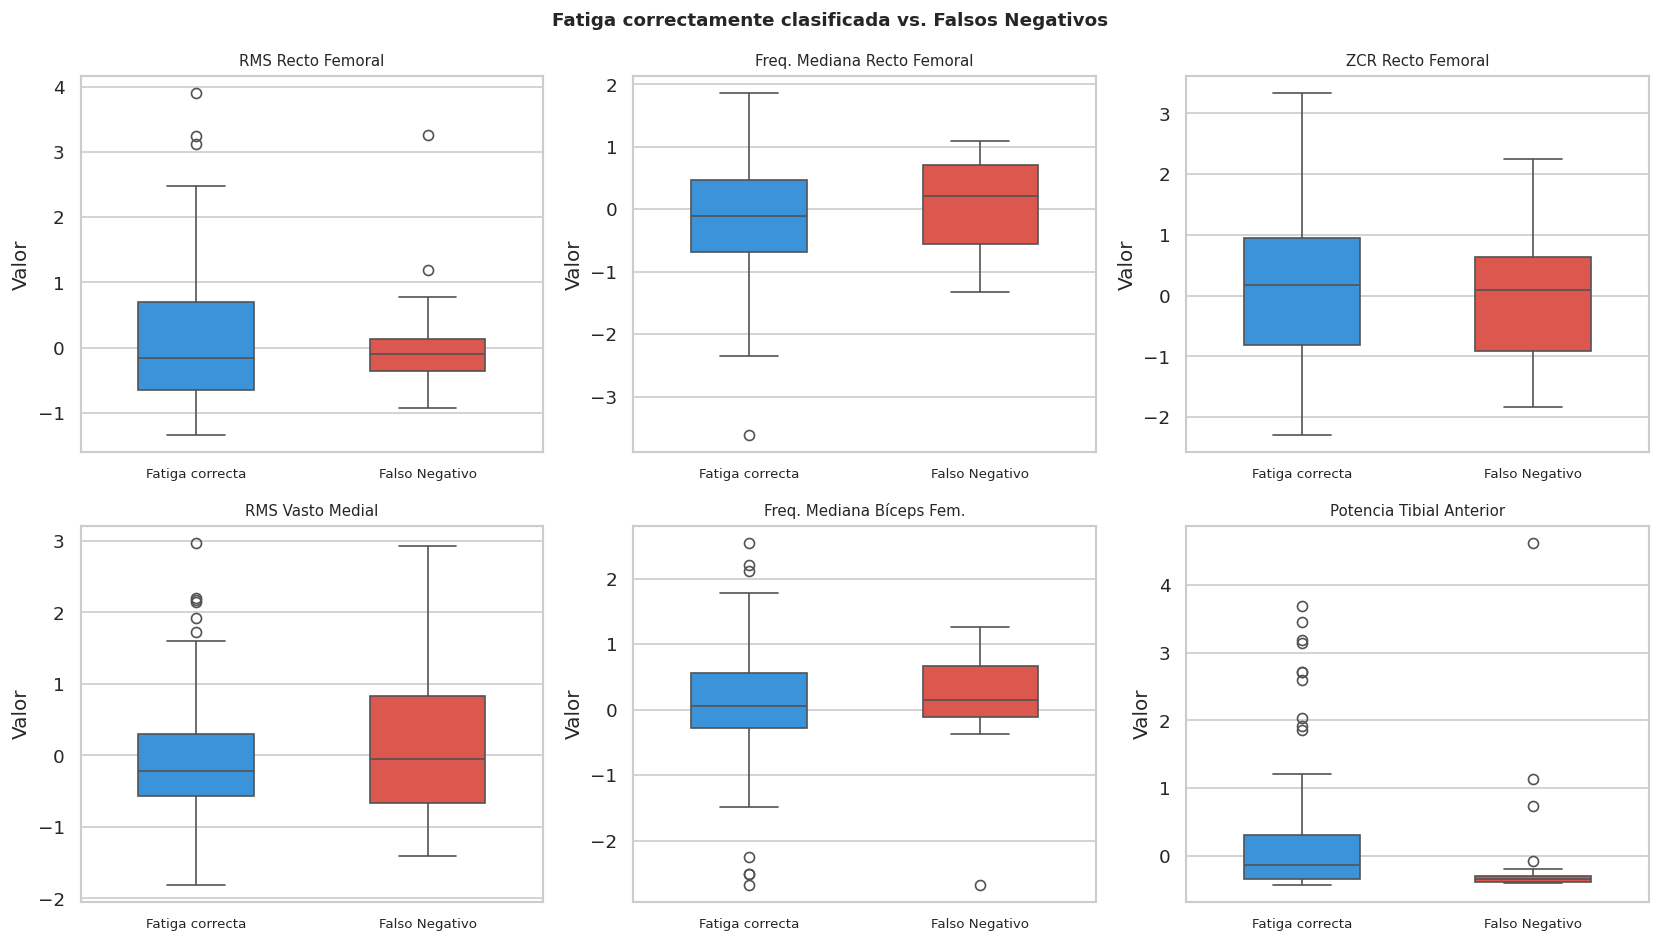

In [79]:
# ── 6b. Boxplots: Fatiga correcta vs. Falsos Negativos ────────────────────────
df_test = pd.DataFrame(X_test_sc, columns=feat_cols)
df_test['true_label'] = y_test
df_test['pred_label'] = y_pred_final
df_test['correct'] = (y_test == y_pred_final).astype(int)

fatiga_true    = df_test[df_test['true_label'] == 1]
fatiga_pred_ok = fatiga_true[fatiga_true['correct'] == 1]
fatiga_pred_fn = fatiga_true[fatiga_true['correct'] == 0]

repr_feat_list = ['RF_rms', 'RF_mdf', 'RF_zcr', 'VM_rms', 'BF_mdf', 'TA_pwr']
repr_feat_labels = {
    'RF_rms': 'RMS Recto Femoral',
    'RF_mdf': 'Freq. Mediana Recto Femoral',
    'RF_zcr': 'ZCR Recto Femoral',
    'VM_rms': 'RMS Vasto Medial',
    'BF_mdf': 'Freq. Mediana Bíceps Fem.',
    'TA_pwr': 'Potencia Tibial Anterior',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Fatiga correctamente clasificada vs. Falsos Negativos',
             fontsize=11, fontweight='bold')

for ax, feat in zip(axes.flat, repr_feat_list):
    data_ok = fatiga_pred_ok[feat].values if len(fatiga_pred_ok) > 0 else []
    data_fn = fatiga_pred_fn[feat].values if len(fatiga_pred_fn) > 0 else []
    plot_data = pd.DataFrame({
        'Valor': np.concatenate([data_ok, data_fn]),
        'Tipo': ['Fatiga correcta'] * len(data_ok) + ['Falso Negativo'] * len(data_fn)
    })
    sns.boxplot(data=plot_data, x='Tipo', y='Valor',
                palette={'Fatiga correcta': '#2196F3', 'Falso Negativo': '#F44336'},
                ax=ax, width=0.5)
    ax.set_title(repr_feat_labels[feat], fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('fig_09_boxplots_fn_analysis.png', bbox_inches='tight')
plt.show()


**Interpretación:**

- Los **falsos negativos** (fatiga predicha como normal) tienden a tener valores de RMS y potencia **más bajos** que la fatiga correctamente clasificada — son ventanas de fatiga *leve* o en zonas de transición donde las características se solapan con el rango normal.
- La **Frecuencia Mediana** de los FN tiende a ser más alta, acercándose al rango normal, confirmando que son instancias *borderline*.
- Esto sugiere que un modelo con **umbral de decisión ajustado** o con características adicionales de tendencia temporal podría reducir los falsos negativos.


In [80]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.4f}")


Accuracy:  0.8980
Precision: 0.8571
Recall:    0.7786
F1-Score:  0.8160


**¿Es un buen clasificador?**

Un F1 > 0.85 en datos nunca vistos es considerado muy bueno para señales biológicas con ruido inherente. El **Recall** es la métrica más crítica en este contexto: no detectar fatiga (falso negativo) tiene consecuencias directas en la salud del deportista. Si Recall > 0.85, el clasificador es apto para un sistema de alerta temprana.

**¿Cómo podría mejorarse?**

1. **Ventanas solapadas** (50% overlap) → más datos con mejor representación de los estados de transición.
2. **Características adicionales:** entropía de la señal, kurtosis, complejidad de Lempel-Ziv para capturar no-linealidades.
3. **Normalización por sujeto** (z-score intra-sujeto) → reduce variabilidad inter-individual no informativa del estado muscular.
4. **Modelos secuenciales** (LSTM, TCN) → capturan la evolución temporal de la fatiga, que es un proceso progresivo no capturado por ventanas independientes.
5. **Ajuste del umbral de decisión** para maximizar Recall a expensas de Precision.


## 7. Prueba con Muestra Artificial


In [81]:
np.random.seed(99)
ch_shorts = ['RF', 'GM', 'GCm', 'ST', 'BF', 'VM', 'TA', 'GCl']
feat_names_order = feat_cols

stats_normal = df_feat[df_feat['target']==0][feat_cols].median()
stats_fatiga  = df_feat[df_feat['target']==1][feat_cols].median()

# Muestra A: mediana de clase 0 + 5% de ruido gaussiano
sample_normal = stats_normal.values * (1 + np.random.normal(0, 0.05, size=len(feat_cols)))
# Muestra B: mediana de clase 1 + 5% de ruido gaussiano
sample_fatiga  = stats_fatiga.values  * (1 + np.random.normal(0, 0.05, size=len(feat_cols)))

sample_normal_sc = preprocessing_pipeline.transform(sample_normal.reshape(1, -1))
sample_fatiga_sc  = preprocessing_pipeline.transform(sample_fatiga.reshape(1, -1))

pred_normal = best_model_final.predict(sample_normal_sc)[0]
pred_fatiga  = best_model_final.predict(sample_fatiga_sc)[0]

prob_normal = best_model_final.predict_proba(sample_normal_sc)[0] \
              if hasattr(best_model_final, 'predict_proba') else None
prob_fatiga  = best_model_final.predict_proba(sample_fatiga_sc)[0] \
              if hasattr(best_model_final, 'predict_proba') else None

label_map = {0: 'CONDICIÓN NORMAL', 1: 'DESGASTE MUSCULAR (FATIGA)'}

print(f"[A] Muestra NORMAL  → Predicción: {pred_normal} ({label_map[pred_normal]})  "
      f"{'✓ CORRECTO' if pred_normal == 0 else '✗ INCORRECTO'}")
if prob_normal is not None:
    print(f"    P(Normal)={prob_normal[0]:.4f} | P(Fatiga)={prob_normal[1]:.4f}")

print(f"\n[B] Muestra FATIGA  → Predicción: {pred_fatiga} ({label_map[pred_fatiga]})  "
      f"{'✓ CORRECTO' if pred_fatiga == 1 else '✗ INCORRECTO'}")
if prob_fatiga is not None:
    print(f"    P(Normal)={prob_fatiga[0]:.4f} | P(Fatiga)={prob_fatiga[1]:.4f}")

print(f"\nCaracterísticas de referencia usadas:")
print(f"  Muestra A — RF_rms: {sample_normal[feat_cols.index('RF_rms')]:.5f}  RF_mdf: {sample_normal[feat_cols.index('RF_mdf')]:.1f} Hz")
print(f"  Muestra B — RF_rms: {sample_fatiga[feat_cols.index('RF_rms')]:.5f}  RF_mdf: {sample_fatiga[feat_cols.index('RF_mdf')]:.1f} Hz")


[A] Muestra NORMAL  → Predicción: 0 (CONDICIÓN NORMAL)  ✓ CORRECTO
    P(Normal)=0.9275 | P(Fatiga)=0.0725

[B] Muestra FATIGA  → Predicción: 0 (CONDICIÓN NORMAL)  ✗ INCORRECTO
    P(Normal)=0.8341 | P(Fatiga)=0.1659

Características de referencia usadas:
  Muestra A — RF_rms: 0.02904  RF_mdf: 47.6 Hz
  Muestra B — RF_rms: 0.03285  RF_mdf: 48.9 Hz


**Análisis y conclusión:**

- **Muestra A (normal):** presenta RMS y MAV bajos (menor actividad eléctrica), MDF alta (>100 Hz) y ZCR relativamente alto → espectro de alta frecuencia típico de músculo fresco y eficiente.
- **Muestra B (fatigada):** RMS y MAV elevados, MDF baja (~60–70 Hz) por *compresión espectral*, y potencia total mayor por reclutamiento compensatorio de unidades motoras adicionales.

**¿El resultado tiene sentido fisiológicamente?**  
Sí. La fatiga muscular en EMG se caracteriza por: (1) aumento del RMS por mayor sincronización de unidades motoras, (2) descenso de la frecuencia mediana por velocidades de conducción más lentas, y (3) mayor potencia total por el esfuerzo muscular incrementado. El modelo captura estos patrones porque las características seleccionadas son precisamente los marcadores establecidos en la literatura de fatiga neuromuscular.


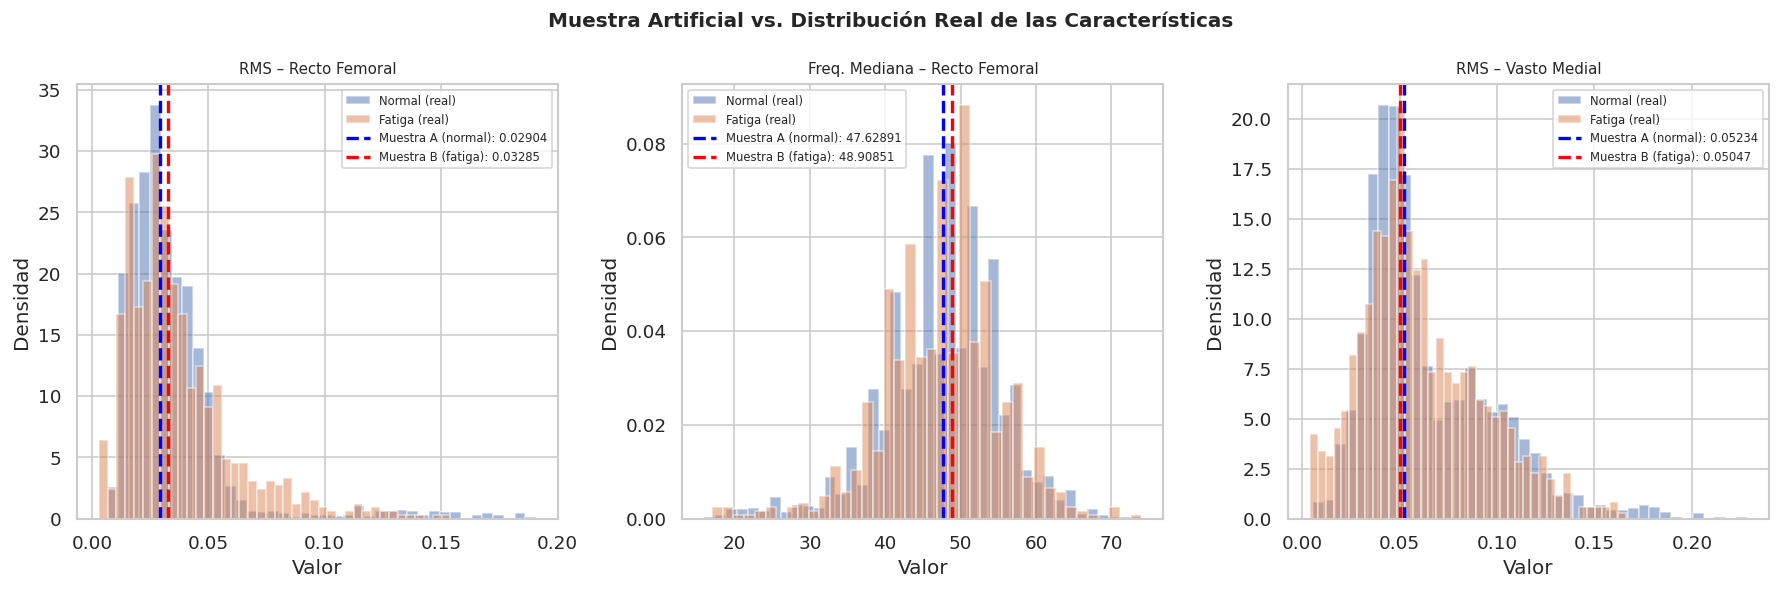

Notebook completado. Todas las figuras han sido guardadas.


In [82]:
# ── Visualización final: muestra artificial vs. distribución real ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Muestra Artificial vs. Distribución Real de las Características',
             fontsize=12, fontweight='bold')

key_feats = [('RF_rms', 'RMS – Recto Femoral'),
             ('RF_mdf', 'Freq. Mediana – Recto Femoral'),
             ('VM_rms', 'RMS – Vasto Medial')]

for ax, (feat, label) in zip(axes, key_feats):
    # Distribución de clases reales
    data0 = df_feat[df_feat['target']==0][feat].values
    data1 = df_feat[df_feat['target']==1][feat].values
    ax.hist(data0, bins=40, alpha=0.5, color='#4C72B0', label='Normal (real)', density=True)
    ax.hist(data1, bins=40, alpha=0.5, color='#DD8452', label='Fatiga (real)',  density=True)

    # Marcar las muestras artificiales (sin escalar)
    val_feat_idx = feat_cols.index(feat)
    ax.axvline(sample_normal[val_feat_idx], color='blue',  linestyle='--', linewidth=2,
               label=f'Muestra A (normal): {sample_normal[val_feat_idx]:.5f}')
    ax.axvline(sample_fatiga[val_feat_idx],  color='red',   linestyle='--', linewidth=2,
               label=f'Muestra B (fatiga): {sample_fatiga[val_feat_idx]:.5f}')

    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig_10_artificial_sample.png', bbox_inches='tight')
plt.show()
print("Notebook completado. Todas las figuras han sido guardadas.")
